# **1. Conociendo la DB**

***La base de datos a utilizar es de la contaminación (GEE Estados) que existe por estados y de forma internacional en Brasil. La DB (Data Base) está en idioma portugués por lo que se recomienda traducir el nombre de las variables en caso que haya complicaciones por los idiomas***

---
- *Dados Estaduais - Desde la versión 2.0 del SEEG las emisiones nacionales son asignadas a los estados y distrito federal. Cuando no fue posible definir el estado donde asignar las emisiones aparece en el campo de estado la sigla "NA" que significa "No Asignado". En promedio la asignación abarca cerca del 96% de los datos de emisión de cada año. Vale notar sin embargo que lo no asignado está concentrado en energía y procesos industriales y por lo tanto al evaluar emisiones por estado para estos sectores se debe tener cautela en el uso de los datos.*

- *[Emissões Brutas] y [Emissões Líquidas] - notar que los datos pueden ser de emisiones o remociones (por cambios de uso de la tierra, vegetación secundaria o bosques en áreas protegidas). Cuando considera solamente las emisiones sin las remociones llamamos EMISIONES BRUTAS. Cuando considera también las remociones se considera EMISIONES NETAS*

- *[Emissões NCI] y [Remoções NCI] - son emisiones y remociones estimadas por el SEEG pero que no están incluidas en el inventario nacional de emisiones. Son incluidas especialmente en el sector agropecuario donde las variaciones de carbono en el suelo de acuerdo con la práctica agrícola aplicada tienen impacto directo para el cumplimiento de las metas de Brasil junto al Acuerdo de París (INDC/NDC)*

## *1.1 Importar DB y bibliotecas*

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot

In [2]:
data = pd.read_excel ('datos/BBDD_contaminacion.xlsx', sheet_name= 'GEE Estados')

c:\Users\Usuario\AppData\Local\Programs\Python\Python311\Lib\site-packages\openpyxl\worksheet\_reader.py:329: UserWarning: Unknown extension is not supported and will be removed
  warn(msg)


In [3]:
df = data.copy()

# **2. ETL**

In [4]:
print (df['Emissão / Remoção / Bunker'].unique())
emisiones_nacionales = ['Emissão']

['Emissão' 'Emissão NCI' 'Remoção NCI' 'Bunker' 'Remoção']


## *2.1 Filtros*

- Bunker son contaminaciones en aguas internacionales así como emisiones NCI, así como las variables de remociones, que no se deben considerar ya que estas "no contaminan" como la variable de emisión, que para este caso sí se utilizará.

In [5]:
df_emisiones = df.query ('`Emissão / Remoção / Bunker` == @emisiones_nacionales')

## *2.2 Duplicados y tipos de dato*

In [6]:
df_emisiones = df_emisiones.drop_duplicates()

In [7]:
print (df_emisiones.info())


<class 'pandas.core.frame.DataFrame'>
Index: 94748 entries, 0 to 103245
Data columns (total 63 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Nível 1 - Setor             94748 non-null  object 
 1   Nível 2                     94748 non-null  object 
 2   Nível 3                     94689 non-null  object 
 3   Nível 4                     82422 non-null  object 
 4   Nível 5                     92290 non-null  object 
 5   Nível 6                     89207 non-null  object 
 6   Emissão / Remoção / Bunker  94748 non-null  object 
 7   Gás                         94748 non-null  object 
 8   Estado                      88852 non-null  object 
 9   Atividade Econômica         94703 non-null  object 
 10  Produto                     36198 non-null  object 
 11  1970                        94748 non-null  float64
 12  1971                        94748 non-null  float64
 13  1972                        94748 n

## *2.3 Transposición de formato Wide a Long*

- Wide es cuando los datos están acomodados de tal forma que ahorran memoria, generalmente se utiliza con fechas (cuando los años están en columnas distintas y no en una única columna de años)

> ***Si estos datos están sin otras columnas complementarias (o sea, sólo años y el valor) hay que hacer una transposición simple con .T***
> ***De lo contrario, si tiene columnas complementarias (tipo de producto/lugar/region/precio, etc) se debe utilizar .melt***

---
- Long es cuando los datos de cada año están en dos columnas que almacenan los datos de cada año, una columna de años donde está cada uno respectivamente y otra de el valor correspondiente a ese año


In [8]:
df_limpio = df_emisiones.melt (id_vars= df_emisiones.columns[0:11], value_vars= df_emisiones.columns[11:], var_name= 'anio', value_name= 'valor_emision')

# **3. Análisis**

In [9]:
df_limpio.drop_duplicates(inplace=True)

In [10]:
print (df_limpio.columns)
print (df_limpio['Atividade Econômica'].unique())

Index(['Nível 1 - Setor', 'Nível 2', 'Nível 3', 'Nível 4', 'Nível 5',
       'Nível 6', 'Emissão / Remoção / Bunker', 'Gás', 'Estado',
       'Atividade Econômica', 'Produto', 'anio', 'valor_emision'],
      dtype='object')
['OUTRA_IND' 'CIM' 'MET' 'HFC' 'ENE_ELET' 'AGR' 'PEC' 'AGROPEC' 'COM'
 'PROD_COMB' 'PUB' 'RES' 'TRAN_PASS' 'TRAN_CARGA' nan 'SANEAMENTO']


## *3.1 Contaminación agropecuaria*
> *¿Cuál es la contaminación media emitida por tipo de gas en el sector Agropecuario?*

In [56]:
df_limpio.query ('`Atividade Econômica` == "AGROPEC"') \
            .groupby ('Gás')[['valor_emision']] \
            .mean().sort_values('valor_emision') \
            [::-1].reset_index()

,Gás,valor_emision
0,CO2 (t),434080.768394
1,CO2e (t) GWP-AR6,429586.156046
2,CO2e (t) GWP-AR4,427622.818149
3,CO2e (t) GWP-AR2,424231.966194
4,CO2e (t) GWP-AR5,408171.854165
5,CO2e (t) GTP-AR2,408144.422354
6,CO2e (t) GTP-AR4,408144.422354
7,CO2e (t) GTP-AR6,407417.278441
8,CO2e (t) GTP-AR5,406178.052709
9,CH4 (t),7031.805507


## *3.2 Ejercicios:*

- Agrupe los datos según la columna "Nível 1 - Setor" para ver el diccionario que contiene las llaves de los grupos formados y la lista de índices para cada grupo.
- Agrupe los datos según la columna "Nível 1 - Setor" y ubique los datos del grupo "Agropecuária".
- Agrupe los datos con base en la columna “Nível 1 - Setor” para identificar la emisión promedio de cada actividad económica en 2021.
- Agrupe los datos con base en la columna "Nível 1 - Setor" para identificar la suma de emisiones de cada actividad económica. Ordene los datos de mayor a menor emisión.

## **Gráficos**

<Axes: xlabel='anio'>

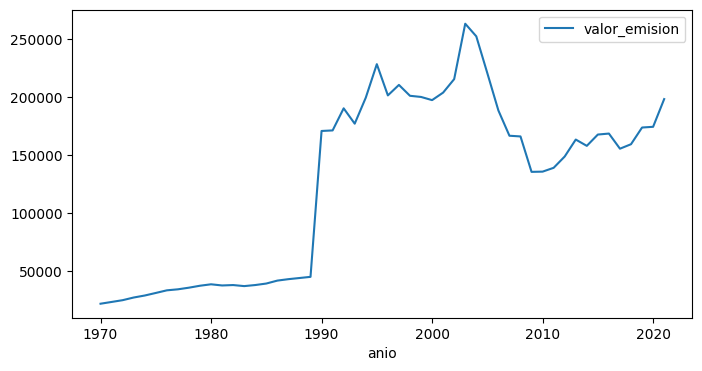

In [23]:
# TODAS LAS COLUMNAS NUMERICAS (en este caso sólo es una)
df_limpio.groupby('anio') \
         .mean(numeric_only=True) \
         .plot(figsize=(8,4))

## *Regresión polinomial*

Lo siguiente es de ejemplo, no es una función ajustada correctamente ni mucho menos con errores bajos, es sólo para ejercicio.

*Año con mayor contaminación media:*
- Para este caso se utiliza la función .idxmax que muestra el índice donde el/los valor/es más alto/s del/los eje(s) "Y" en el gráfico de líneas.
- Es el mismo resultado que si se obtuviera la derivada = 0 de una función representativa de la tendencia de los datos observados, es decir:

***La función que modela a los datos*** $$y = 47,057,690,812.10 - 71044851.8x + 35749.43x^2 - 5.996x^3$$

---
***La derivada parcial de la función que modela = 0 (pendiente cero: valor máximo)***

$$\frac{\partial y}{\partial x} = 0$$




In [42]:
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
import matplotlib.pyplot as plt

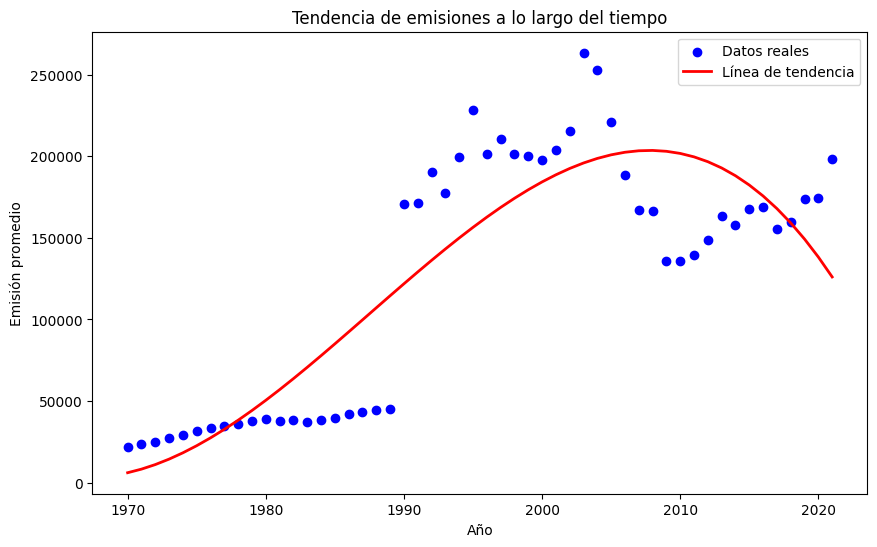

47057690812.10123
[ 0.00000000e+00 -7.10448518e+07  3.57494261e+04 -5.99568844e+00]


In [54]:
anios = df_limpio['anio'].unique().reshape (-1,1)
emisiones_medias = df_limpio.groupby('anio')['valor_emision'].mean().values

poly = PolynomialFeatures (degree= 3)
anios_poly = poly.fit_transform (anios)

modelo1 = LinearRegression ()
modelo1.fit (anios_poly, emisiones_medias)
modelo1_pred = modelo1.predict (anios_poly)

plt.figure(figsize=(10, 6))
plt.scatter(anios, emisiones_medias, label='Datos reales', color='blue')
plt.plot(anios, modelo1_pred, label='Línea de tendencia', color='red', linewidth=2)
plt.xlabel('Año')
plt.ylabel('Emisión promedio')
plt.title('Tendencia de emisiones a lo largo del tiempo')
plt.legend()
plt.show()

print (modelo1.intercept_)
print (modelo1.coef_)

In [55]:
# AÑO CON MAYOR CONTAMINACIÓN MEDIA
df_limpio.groupby ('anio') \
         .mean (numeric_only=True) \
         .idxmax()

valor_emision    2003
dtype: int64

## *Pivot Table (Tabla Dinámica)*

In [64]:
# Contaminación por gases a través del tiempo
df_limpio.groupby (['anio', 'Gás']) \
         .mean (numeric_only=True) \
         .reset_index()

,anio,Gás,valor_emision
0,1970,C2F6 (t),0.232610
1,1970,CF4 (t),3.557421
2,1970,CH4 (t),1471.024024
3,1970,CO (t),2155.556658
4,1970,CO2 (t),19244.913199
...,...,...,...
1191,2021,HFC-23 (t),0.000000
1192,2021,HFC-32 (t),261.100000
1193,2021,N2O (t),119.295311
1194,2021,NOx (t),679.395431


***Dado lo anterior, no se puede graficar en un gráfico de líneas cada tipo de gas con una línea distinta, es por eso que se utiliza .pivot_table para realizar este tipo de análisis***

In [82]:
df_emisiones_por_gas = df_limpio.pivot_table (index = 'anio', columns = 'Gás', values = 'valor_emision')
df_emisiones_por_gas.head()

Gás,C2F6 (t),CF4 (t),CH4 (t),CO (t),CO2 (t),CO2e (t) GTP-AR2,CO2e (t) GTP-AR4,CO2e (t) GTP-AR5,CO2e (t) GTP-AR6,CO2e (t) GWP-AR2,...,COVNM (t),HFC-125 (t),HFC-134a (t),HFC-143a (t),HFC-152a (t),HFC-23 (t),HFC-32 (t),N2O (t),NOx (t),SF6 (t)
anio,,,,,,,,,,,,,,,,,,,,,
1970,0.232610,3.557421,1471.024024,2155.556658,19244.913199,20821.379814,20821.379814,19162.726020,19775.283385,35396.183865,...,742.074863,0.0,0.0,0.0,0.0,0.0,0.0,31.632709,154.072797,0.0
1971,0.334611,5.117360,1525.506914,2259.625805,21598.587743,22466.288595,22466.288595,20748.481445,21386.175802,37570.982886,...,730.119047,0.0,0.0,0.0,0.0,0.0,0.0,32.609237,170.550178,0.0
1972,0.404684,6.189025,1584.719568,2418.944795,23664.445521,24100.305265,24100.305265,22303.224240,22966.797327,39800.768350,...,774.278817,0.0,0.0,0.0,0.0,0.0,0.0,34.311864,188.856161,0.0
1973,0.463147,7.083136,1642.612439,2596.053853,27726.668829,26683.827206,26683.827206,24827.077028,25516.409611,42947.755490,...,796.866394,0.0,0.0,0.0,0.0,0.0,0.0,35.278689,217.320480,0.0
1974,0.471026,7.203619,1704.614365,2681.450599,30155.918952,28539.318732,28539.318732,26600.481407,27321.124852,45431.240064,...,1024.694923,0.0,0.0,0.0,0.0,0.0,0.0,37.098183,247.521415,0.0


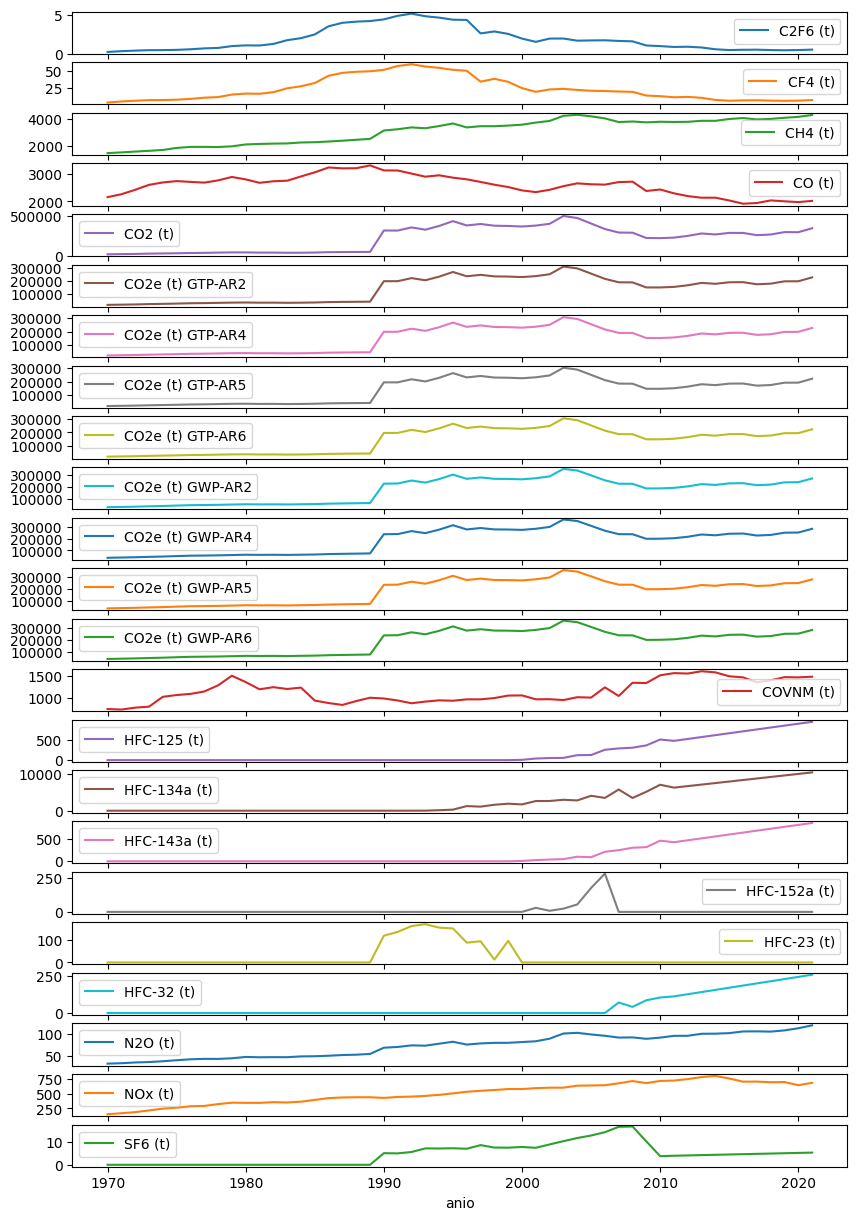

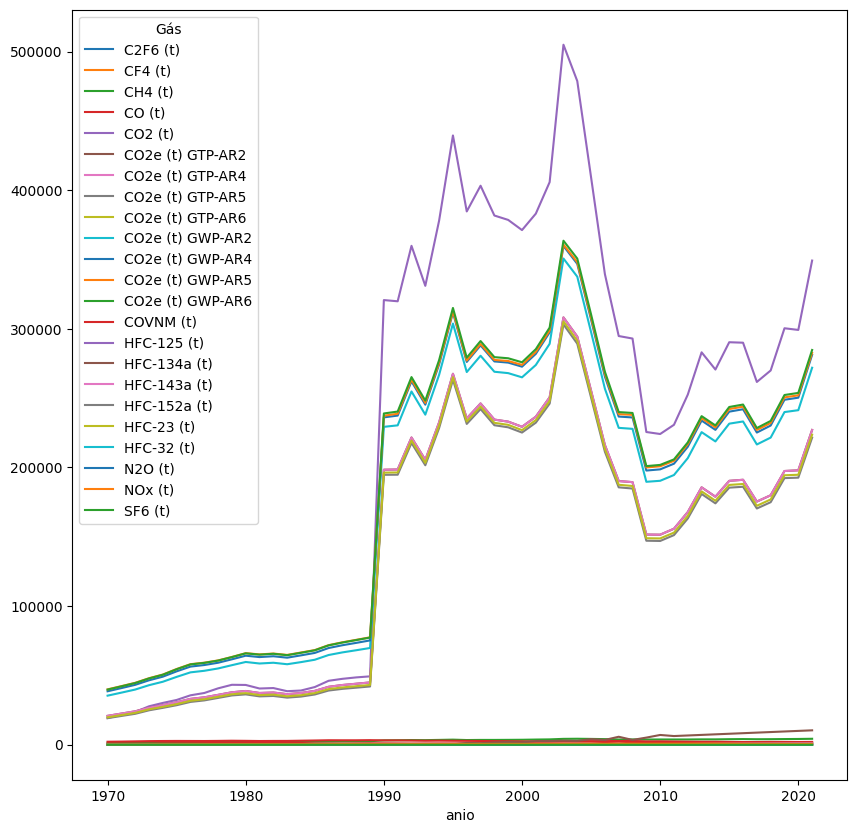

In [83]:
# Evalúa con un gráfico para cada gas que exista en el dataframe (muy extenso)
df_emisiones_por_gas.plot (subplots=True, figsize= (10,15)) # Mejor ajustar con (10,40)

# Más simple, un gráfico con múltiples líneas
df_emisiones_por_gas.plot (figsize= (10,10))
plt.show()